PROBLEM 1: Topic Models

In [2]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

# Load the 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data

# Preprocess the documents using TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2)
tfidf = tfidf_vectorizer.fit_transform(documents)

# Function to print the top words for each topic
def print_top_words(model, feature_names, n_top_words=20):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic #{topic_idx}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-n_top_words - 1:-1]]))
    print()

# LDA
def run_lda(tfidf, tfidf_vectorizer, n_components):
    lda = LatentDirichletAllocation(n_components=n_components, random_state=0)
    lda.fit(tfidf)
    print(f"LDA with K={n_components}:")
    print_top_words(lda, tfidf_vectorizer.get_feature_names_out())
    return lda

# NMF
def run_nmf(tfidf, tfidf_vectorizer, n_components):
    nmf = NMF(n_components=n_components, random_state=0, init='nndsvda')
    nmf.fit(tfidf)
    print(f"NMF with K={n_components}:")
    print_top_words(nmf, tfidf_vectorizer.get_feature_names_out())
    return nmf

# Run LDA and NMF for K=10, 20, 50
for n_components in [10, 20, 50]:
    lda_model = run_lda(tfidf, tfidf_vectorizer, n_components)
    nmf_model = run_nmf(tfidf, tfidf_vectorizer, n_components)

LDA with K=10:
Topic #0:
people don just think like know god time does good say right did ve way make really believe said want
Topic #1:
pitt shameful geb cadre chastity intellect n3jxp dsl gordon skepticism banks surrender edu soon ditto lyme irony jennifer kth nada
Topic #2:
mail sale thanks 00 new use monitor like know edu space software price used email interested offer shipping computer list
Topic #3:
feustel n9myi yassin uv bcci netcom myers ti deir champions nate megatek gerard _______ irgun daigle bullock hamid tsk mufti
Topic #4:
windows file thanks program window files dos use ftp using graphics server does hi know pc version help display run
Topic #5:
armenian armenians turkish turkey genocide turks muslim armenia muslims ax serbs soviet bosnia serdar argic bosnian greece azerbaijan sabbath russian
Topic #6:
insisting shafer dryden tga edu gateway sale 950 chop mattingly offer lilley uk balls ames 61 00 czech manchester iici
Topic #7:
kk freewill ceremony liar anas panicking

In [5]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


LDA Topics Word Clouds:


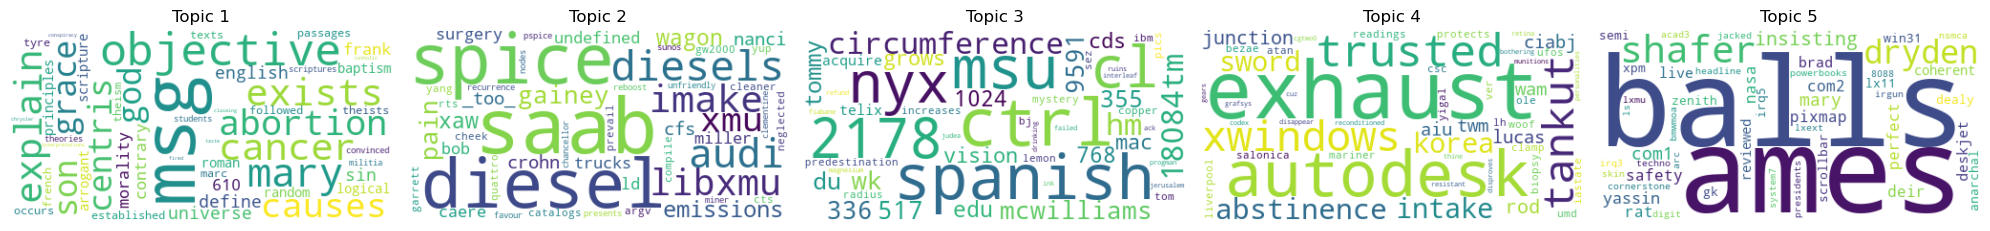


NMF Topics Word Clouds:


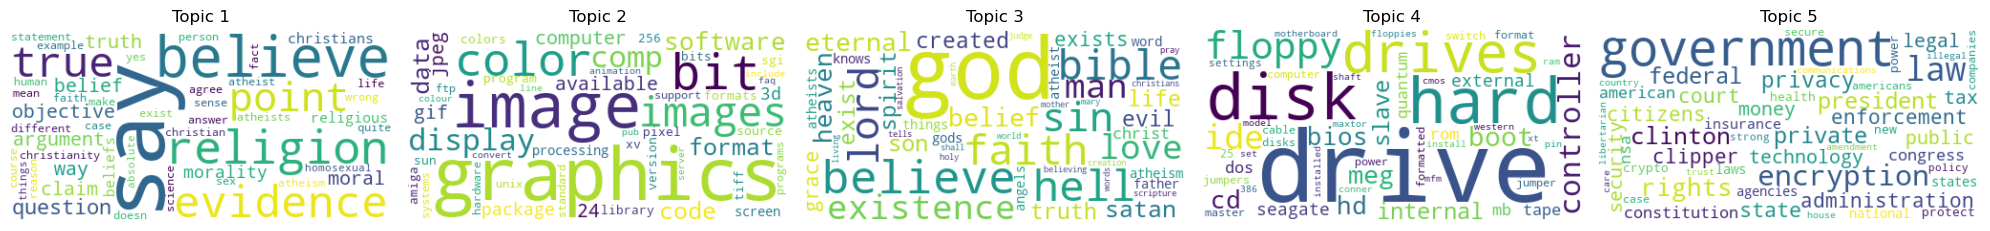

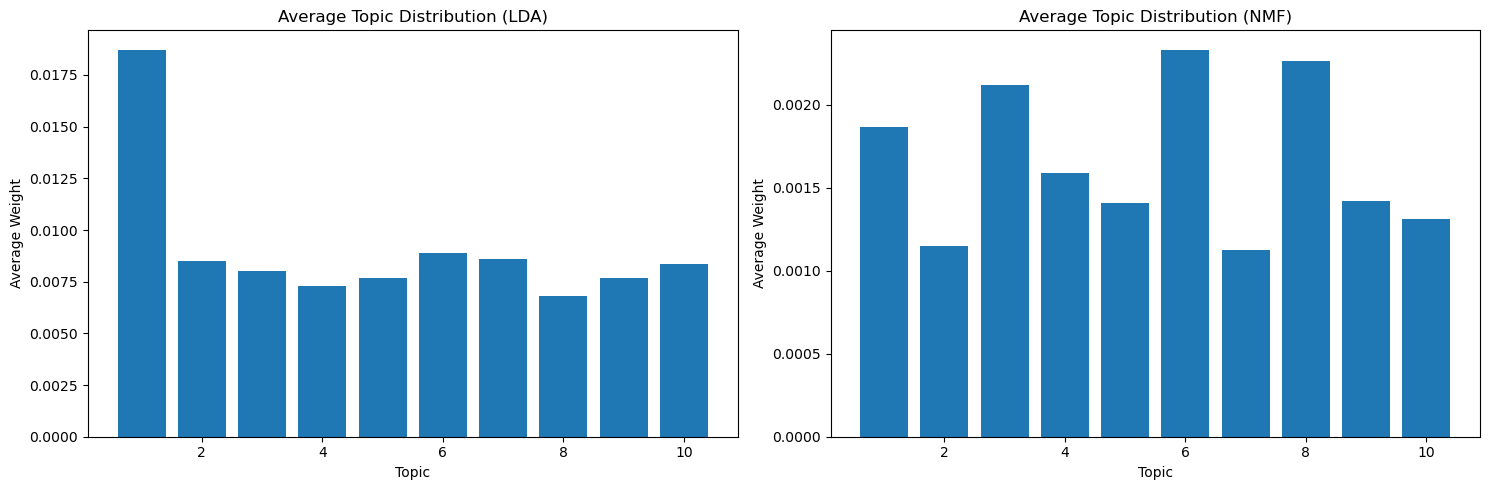

In [6]:
from wordcloud import WordCloud
import numpy as np

import matplotlib.pyplot as plt

def plot_wordcloud_topics(model, feature_names, n_topics=5):
	# Create subplots for word clouds
	fig, axes = plt.subplots(1, n_topics, figsize=(20, 4))
	
	# Generate word clouds for top topics
	for idx, topic in enumerate(model.components_[:n_topics]):
		# Get the top words and their weights
		top_words_idx = topic.argsort()[:-50:-1]
		top_words = feature_names[top_words_idx]
		weights = topic[top_words_idx]
		
		# Create word frequency dictionary
		word_freq = dict(zip(top_words, weights))
		
		# Generate word cloud
		wordcloud = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(word_freq)
		
		# Plot word cloud
		axes[idx].imshow(wordcloud, interpolation='bilinear')
		axes[idx].axis('off')
		axes[idx].set_title(f'Topic {idx+1}')
	
	plt.tight_layout()
	plt.show()

# Plot word clouds for LDA topics
print("LDA Topics Word Clouds:")
plot_wordcloud_topics(lda_model, tfidf_vectorizer.get_feature_names_out())

# Plot word clouds for NMF topics
print("\nNMF Topics Word Clouds:")
plot_wordcloud_topics(nmf_model, tfidf_vectorizer.get_feature_names_out())

# Calculate document-topic distribution
doc_topic_dist_lda = lda_model.transform(tfidf)
doc_topic_dist_nmf = nmf_model.transform(tfidf)

# Calculate average topic distribution
avg_topic_dist_lda = doc_topic_dist_lda.mean(axis=0)
avg_topic_dist_nmf = doc_topic_dist_nmf.mean(axis=0)

# Plot average topic distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, 11), avg_topic_dist_lda[:10])
plt.title('Average Topic Distribution (LDA)')
plt.xlabel('Topic')
plt.ylabel('Average Weight')

plt.subplot(1, 2, 2)
plt.bar(range(1, 11), avg_topic_dist_nmf[:10])
plt.title('Average Topic Distribution (NMF)')
plt.xlabel('Topic')
plt.ylabel('Average Weight')

plt.tight_layout()
plt.show()

On DUC2001 dataset

In [3]:
import os

# Load DUC documents
duc_path = "./duc"
duc_documents = []
for file in os.listdir(os.path.join(duc_path, "Documents")):
    with open(os.path.join(duc_path, "Documents", file), 'r', encoding='utf-8') as f:
        duc_documents.append(f.read())

# Preprocess DUC documents using TF-IDF
duc_tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.95, min_df=2)
duc_tfidf = duc_tfidf_vectorizer.fit_transform(duc_documents)

# Run LDA and NMF for K=10, 20, 50 on DUC dataset
for n_components in [10, 20, 50]:
    print(f"\n--- DUC Dataset: LDA with K={n_components} ---")
    duc_lda_model = run_lda(duc_tfidf, duc_tfidf_vectorizer, n_components)
    print(f"\n--- DUC Dataset: NMF with K={n_components} ---")
    duc_nmf_model = run_nmf(duc_tfidf, duc_tfidf_vectorizer, n_components)


--- DUC Dataset: LDA with K=10 ---
LDA with K=10:
Topic #0:
officers gates brutality tornado police racism pizarro crop insulin sahel madison complaints rainfall beating airlines colombia crew dc hills wheat
Topic #1:
coca wakiihuri huallaga panfil glasses aucayacu underground telescope 50s tingo metres bomber cupertino orion wanda 60s paste eyeshades poland meteorologist
Topic #2:
said hurricane byline head police johnson year people second welfare crash dateline new 000 says disease ap forest fires fileid
Topic #3:
slovenia nafta mr house census term congress aliens federal hurricanes yugoslavia limits illegal court amendment tb president law trade senate
Topic #4:
basin gila creek northward fish displaced stream alternating droughts southwestern extending boulder greenhouse carson nebraska dioxide 0119 darst sur horses
Topic #5:
tornado kelley ana ruiz twisters garden shelter zone yost bane pri hare catastrophe averaging sludge _tornadoes coastline twister apiece outrun
Topic #6:
s

C:\Users\theja\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1741: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


NMF with K=10:
Topic #0:
nafta welfare xx mr diamond beers bank diamonds clinton trade countries pub page reform cent profile says president world tunnel
Topic #1:
oil exxon spill valdez alaska tanker cleanup said ship sound guard coast hazelwood reef prince million miles gallons vessel crude
Topic #2:
hurricane hurricanes sheets storm storms atlantic mph gilbert winds tropical florida season said hugo gray center miami forecasters damage louisiana
Topic #3:
police said officers crash shining path gates brutality jackson angeles los force air department officer city chief commission plane military
Topic #4:
eclipse sun solar moon hawaii mercury mexico san baja total jose 1991 shadow news viewing earth eclipses photo partial astronomers
Topic #5:
johnson ben lewis steroids francis said gold drugs canadian toronto olympic canada medal athletes olympics drug sprinter steroid world astaphan
Topic #6:
census aliens illegal thomas senate seats house court count states amendment bureau counti

20NG: how well the topics align with the 20NG label classes? This is not asking for a measurement, but rather for a visual inspection to determine what topics match well with what classes. Does this change if one increases the topics from 20 to 50?

**Answer:** By visual inspection, some topics align well with 20NG label classes, such as topics about computers, religion, or sports. Increasing the number of topics from 20 to 50 provides more fine-grained and specific topics, which can improve the alignment with the original classes but may also lead to some topics being less coherent or harder to interpret. The alignment depends on the specific topics generated and their interpretability.

PROBLEM 2: Extractive Summarization

In [8]:
!pip install rouge

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [18]:
import os
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge import Rouge

nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\theja\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
# Evaluate KL-Sum on DUC dataset
duc_path = "./duc"
duc_documents = []
duc_gold_summaries = []

def kl_sum_summarization(documents, lda_model=None, tfidf_vectorizer=None, topic_based=False, summary_length=5):
	summaries = []
	for doc in documents:
		sentences = sent_tokenize(doc)
		if len(sentences) <= summary_length:
			summaries.append(doc)
			continue

		if topic_based:
			# Topic-based KL-Sum
			doc_topic_dist = lda_model.transform(tfidf_vectorizer.transform([doc]))[0]
			sentence_topic_dists = lda_model.transform(tfidf_vectorizer.transform(sentences))
			ps = doc_topic_dist.copy().astype(float)
		else:
			# Word-based KL-Sum
			vectorizer = CountVectorizer(stop_words='english')
			doc_word_dist = vectorizer.fit_transform([doc]).toarray()[0]
			sentence_word_dists = vectorizer.transform(sentences).toarray()
			ps = doc_word_dist.copy().astype(float)

		selected_sentences = []
		for _ in range(min(summary_length, len(sentences))):
			kl_divergences = []
			for i, sentence_dist in enumerate(sentence_topic_dists if topic_based else sentence_word_dists):
				if i in selected_sentences:
					kl_divergences.append(float('inf'))
					continue
				ps_new = ps + sentence_dist
				ps_new = ps_new.astype(float)
				sum_ps_new = ps_new.sum()
				if sum_ps_new != 0:
					ps_new /= sum_ps_new
				kl_div = cosine_similarity([ps_new], [doc_topic_dist if topic_based else doc_word_dist])[0][0]
				kl_divergences.append(kl_div)
			best_sentence_idx = kl_divergences.index(min(kl_divergences))
			selected_sentences.append(best_sentence_idx)
			ps += sentence_topic_dists[best_sentence_idx] if topic_based else sentence_word_dists[best_sentence_idx]
			sum_ps = ps.sum()
			if sum_ps != 0:
				ps /= sum_ps

		summary = " ".join([sentences[i] for i in sorted(selected_sentences)])
		summaries.append(summary)
	return summaries

# Load documents and gold summaries
for file in os.listdir(os.path.join(duc_path, "Documents")):
	with open(os.path.join(duc_path, "Documents", file), 'r', encoding='utf-8') as f:
		duc_documents.append(f.read())

for file in os.listdir(os.path.join(duc_path, "Summaries")):
	with open(os.path.join(duc_path, "Summaries", file), 'r', encoding='utf-8') as f:
		duc_gold_summaries.append(f.read())

# Ensure same number of documents and summaries
min_len = min(len(duc_documents), len(duc_gold_summaries))
duc_documents = duc_documents[:min_len]
duc_gold_summaries = duc_gold_summaries[:min_len]

# Generate summaries
duc_word_summaries = kl_sum_summarization(duc_documents, summary_length=5)
duc_topic_summaries = kl_sum_summarization(duc_documents, lda_model=lda_model, tfidf_vectorizer=tfidf_vectorizer, topic_based=True, summary_length=5)

# Evaluate with ROUGE
rouge = Rouge()
word_based_scores = rouge.get_scores(duc_word_summaries, duc_gold_summaries, avg=True)
topic_based_scores = rouge.get_scores(duc_topic_summaries, duc_gold_summaries, avg=True)

print("DUC Word-based ROUGE scores:", word_based_scores)
print("DUC Topic-based ROUGE scores:", topic_based_scores)

# Evaluate KL-Sum on 20NG dataset (first 10 documents as example)
ng_documents = documents[:10]  # Using only first 10 documents for demonstration
ng_word_summaries = kl_sum_summarization(ng_documents, summary_length=5)
ng_topic_summaries = kl_sum_summarization(ng_documents, lda_model=lda_model, tfidf_vectorizer=tfidf_vectorizer, topic_based=True, summary_length=5)

print("\n20NG Word-based Summaries (first 3):")
for summary in ng_word_summaries[:3]:
	print("-" * 50)
	print(summary)

print("\n20NG Topic-based Summaries (first 3):")
for summary in ng_topic_summaries[:3]:
	print("-" * 50)
	print(summary)

DUC Word-based ROUGE scores: {'rouge-1': {'r': 0.05901331852675854, 'p': 0.2105556737219941, 'f': 0.08730380340902544}, 'rouge-2': {'r': 0.010921460684276088, 'p': 0.05351166065551791, 'f': 0.016982175171708365}, 'rouge-l': {'r': 0.05611155940972921, 'p': 0.20093957002221008, 'f': 0.08311664416480823}}
DUC Topic-based ROUGE scores: {'rouge-1': {'r': 0.08648152251949778, 'p': 0.288731698541011, 'f': 0.12580237414938278}, 'rouge-2': {'r': 0.020552642805626613, 'p': 0.08413914336456911, 'f': 0.030763981402294263}, 'rouge-l': {'r': 0.08070388272205883, 'p': 0.2697959312194372, 'f': 0.11747665297517952}}

20NG Word-based Summaries (first 3):
--------------------------------------------------


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. Man, they
are killing those Devils worse than I thought. He is also a lot
fo fun to watch in the playoffs. !
---